In [6]:
import numpy as np
import matplotlib.pyplot as plt
import keras

In [13]:
from keras.datasets import mnist

In [14]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [9]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [10]:
def plot_input_img(i):
    plt.imshow(x_train[i], cmap = 'binary')
    plt.title(y_train[i])
    plt.show

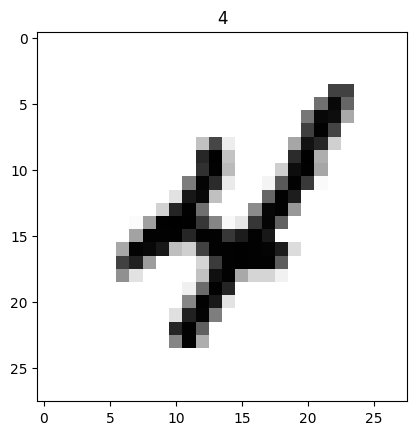

In [12]:
for i in range(10):
    plot_input_img(i)

In [15]:
x_train = x_train.astype(np.float32)/255
x_test = x_test.astype(np.float32)/255

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [16]:
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

In [17]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

In [18]:
model = Sequential()

model.add(Conv2D(32, (3,3), input_shape = (28,28,1), activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

d:\Engr Course\VSCode\ML\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam', loss = keras.losses.categorical_crossentropy, metrics=['accuracy'])

In [21]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor= 'val_accuracy', min_delta= 0.01, patience= 4, verbose= 1)
mc = ModelCheckpoint('./BestModel.h5', monitor= 'val_accuracy', verbose = 1, save_best_only = True)

cb = [es, mc]

In [22]:
history = model.fit(x_train, y_train, epochs = 10, validation_split=0.3, callbacks= cb)

Epoch 1/10
1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8308 - loss: 0.5450
Epoch 1: val_accuracy improved from -inf to 0.97450, saving model to ./BestModel.h5


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.8309 - loss: 0.5446 - val_accuracy: 0.9745 - val_loss: 0.0867
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9690 - loss: 0.1009
Epoch 2: val_accuracy improved from 0.97450 to 0.98206, saving model to ./BestModel.h5


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 74s 42ms/step - accuracy: 0.9690 - loss: 0.1009 - val_accuracy: 0.9821 - val_loss: 0.0605
Epoch 3/10
1312/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9765 - loss: 0.0745
Epoch 3: val_accuracy improved from 0.98206 to 0.98422, saving model to ./BestModel.h5


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 69s 53ms/step - accuracy: 0.9765 - loss: 0.0745 - val_accuracy: 0.9842 - val_loss: 0.0486
Epoch 4/10
1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9809 - loss: 0.0620
Epoch 4: val_accuracy improved from 0.98422 to 0.98556, saving model to ./BestModel.h5


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9809 - loss: 0.0620 - val_accuracy: 0.9856 - val_loss: 0.0472
Epoch 5/10
1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9818 - loss: 0.0550
Epoch 5: val_accuracy improved from 0.98556 to 0.98689, saving model to ./BestModel.h5


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 75s 30ms/step - accuracy: 0.9819 - loss: 0.0550 - val_accuracy: 0.9869 - val_loss: 0.0415
Epoch 6/10
1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9843 - loss: 0.0473
Epoch 6: val_accuracy did not improve from 0.98689
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.9843 - loss: 0.0473 - val_accuracy: 0.9861 - val_loss: 0.0442
Epoch 7/10
1311/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9862 - loss: 0.0450
Epoch 7: val_accuracy improved from 0.98689 to 0.98861, saving model to ./BestModel.h5


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 37ms/step - accuracy: 0.9862 - loss: 0.0450 - val_accuracy: 0.9886 - val_loss: 0.0386
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9869 - loss: 0.0409
Epoch 8: val_accuracy did not improve from 0.98861
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 73s 30ms/step - accuracy: 0.9869 - loss: 0.0409 - val_accuracy: 0.9876 - val_loss: 0.0424
Epoch 8: early stopping


In [23]:
model_s = keras.models.load_model(f'D:\Engr Course\VSCode\ML\BestModel.h5')

In [24]:
score = model_s.evaluate(x_test, y_test)
print(f'Accuracy is {score[1]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9889 - loss: 0.0373
Accuracy is 0.9901000261306763
